# 07 — LOCA severity estimation

This notebook estimates the continuous LOCA severity label defined by NPPAD: file `1.csv` through `100.csv` corresponds to a `1%` through `100%` break of the reference `100 cm²` area. It is a severity-estimation experiment, not a normal-reference early-warning claim.

The feature set is loaded from the 03 audit and is restricted to its 38 `observable_process` candidates. `TIME`, `sample_id`, `severity`, direct break/leak quantities, protection/control actions, radiation/dose variables, and consequence/safety-margin variables are excluded. Each row summarizes one complete LOCA trajectory over one post-injection window.

## Evaluation protocol

- Injection time: `0.5 s`; CSV grid: `10 s`. The strict post-injection rule is `TIME > 0.5` and `TIME <= 0.5 + window`.
- Windows: `30 s`, `60 s`, `120 s`, `300 s`, containing `10–30` (3), `10–60` (6), `10–120` (12), and `10–300 s` (30) samples.
- Features per process variable: last value, change from the `t=0` baseline, mean, population standard deviation, and linear slope.
- Groups are complete trajectories. A deterministic severity-rank cycle creates 60 train, 20 validation, and 20 test trajectories, with low (`1–10`), middle (`11–90`), and high (`91–100`) severities represented in all splits.
- Ridge, Random Forest, Gradient Boosting, and a training-mean naive baseline are compared. Model/window selection uses validation only; test is used once for the final report.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone

PROJECT_ROOT = next((candidate for candidate in [Path.cwd(), *Path.cwd().parents] if (candidate / 'src').is_dir() and (candidate / 'data').is_dir()), Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.severity_features import (
    DEFAULT_FEATURE_GROUPS,
    WINDOWS_S,
    build_severity_features,
    candidate_process_features,
)
from src.severity_models import (
    feature_importance_table,
    make_group_split,
    model_suite,
    regression_metrics,
    suspicious_train_features,
)

RESULTS_ROOT = PROJECT_ROOT / 'results'
FIGURES_ROOT = RESULTS_ROOT / 'figures'
FIGURES_ROOT.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True})
print('Project root detected and local feature audit loaded.')

Project root detected and local feature audit loaded.


In [2]:
feature_groups = pd.read_csv(DEFAULT_FEATURE_GROUPS)
candidate_features = candidate_process_features(DEFAULT_FEATURE_GROUPS)
assert len(candidate_features) == 38
assert set(feature_groups.loc[feature_groups['ml_policy'].eq('candidate'), 'feature']) == set(candidate_features)

dataset, point_rows = build_severity_features(features=candidate_features)
metadata_columns = {'sample_id', 'severity', 'window_s'}
feature_columns = [column for column in dataset.columns if column not in metadata_columns]
assert dataset.shape == (400, 3 + 38 * 5)
assert len(feature_columns) == 190
assert dataset['sample_id'].nunique() == 100
assert set(dataset['window_s']) == set(WINDOWS_S)
assert dataset[feature_columns].notna().all().all()
assert all(column.split('__', 1)[0] in candidate_features for column in feature_columns)

window_summary = (
    point_rows.groupby('window_s', as_index=False)
    .agg(
        trajectory_count=('sample_id', 'nunique'),
        sample_count=('sample_count', 'first'),
        first_sample_s=('first_sample_s', 'first'),
        last_sample_s=('last_sample_s', 'first'),
        sample_points_s=('sample_points_s', 'first'),
        sample_count_values=('sample_count', 'nunique'),
        point_pattern_values=('sample_points_s', 'nunique'),
    )
)
expected_points = {
    30: (3, '10,20,30'),
    60: (6, '10,20,30,40,50,60'),
    120: (12, '10,20,30,40,50,60,70,80,90,100,110,120'),
    300: (30, '10,20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250,260,270,280,290,300'),
}
for row in window_summary.itertuples():
    expected_count, expected_pattern = expected_points[int(row.window_s)]
    assert row.trajectory_count == 100
    assert row.sample_count == expected_count
    assert row.sample_count_values == 1
    assert row.point_pattern_values == 1
    assert row.sample_points_s == expected_pattern

display(window_summary.drop(columns=['sample_count_values', 'point_pattern_values']))
print(f'Built {len(dataset)} trajectory-window rows and {len(feature_columns)} features from {len(candidate_features)} audited process variables.')

,window_s,trajectory_count,sample_count,first_sample_s,last_sample_s,sample_points_s
0,30,100,3,10.0,30.0,"10,20,30"
1,60,100,6,10.0,60.0,"10,20,30,40,50,60"
2,120,100,12,10.0,120.0,"10,20,30,40,50,60,70,80,90,100,110,120"
3,300,100,30,10.0,300.0,"10,20,30,40,50,60,70,80,90,100,110,120,130,140..."


Built 400 trajectory-window rows and 190 features from 38 audited process variables.


In [3]:
split_manifest = make_group_split(dataset['sample_id'].unique().tolist())
assert split_manifest['sample_id'].nunique() == 100
assert split_manifest['split'].value_counts().to_dict() == {'train': 60, 'validation': 20, 'test': 20}

def severity_band(value):
    if value <= 10:
        return 'low_1_10'
    if value <= 90:
        return 'middle_11_90'
    return 'high_91_100'

split_manifest['severity_band'] = split_manifest['severity'].map(severity_band)
band_table = pd.crosstab(split_manifest['severity_band'], split_manifest['split'])
assert (band_table > 0).all().all()

dataset = dataset.merge(split_manifest[['sample_id', 'split']], on='sample_id', how='left', validate='many_to_one')
assert dataset['split'].notna().all()
assert dataset.groupby('sample_id')['split'].nunique().eq(1).all()

split_manifest.to_csv(RESULTS_ROOT / '07_severity_split.csv', index=False)
window_summary.to_csv(RESULTS_ROOT / '07_window_sample_points.csv', index=False)
display(band_table)
display(split_manifest.head(12))

split,test,train,validation
severity_band,,,
high_91_100,2,6,2
low_1_10,2,6,2
middle_11_90,16,48,16


,sample_id,severity,split,severity_band
0,LOCA_001,1,test,low_1_10
1,LOCA_002,2,validation,low_1_10
2,LOCA_003,3,train,low_1_10
3,LOCA_004,4,train,low_1_10
4,LOCA_005,5,train,low_1_10
5,LOCA_006,6,test,low_1_10
6,LOCA_007,7,validation,low_1_10
7,LOCA_008,8,train,low_1_10
8,LOCA_009,9,train,low_1_10
9,LOCA_010,10,train,low_1_10


In [4]:
forbidden_base_features = set(feature_groups.loc[feature_groups['ml_policy'].ne('candidate'), 'feature'])
base_feature_names = {column.split('__', 1)[0] for column in feature_columns}
assert not base_feature_names.intersection(forbidden_base_features)
assert not any(token in column.lower() for column in feature_columns for token in ('severity', 'sample_id', 'source_file'))

leakage_rows = []
flagged_by_window = {}
for window_s in WINDOWS_S:
    train_rows = dataset.loc[(dataset['window_s'].eq(window_s)) & dataset['split'].eq('train')]
    audit = suspicious_train_features(train_rows[feature_columns], train_rows['severity'], threshold=0.95)
    audit['window_s'] = window_s
    audit['base_feature'] = audit['feature'].str.split('__', n=1).str[0]
    leakage_rows.append(audit)
    flagged_by_window[window_s] = set(audit.loc[audit['flagged'], 'feature'])

leakage_audit = pd.concat(leakage_rows, ignore_index=True)
leakage_audit = leakage_audit[['window_s', 'feature', 'base_feature', 'train_abs_correlation', 'flagged']]
leakage_audit.to_csv(RESULTS_ROOT / '07_leakage_audit.csv', index=False)
print('Train-only suspicious-feature threshold: |correlation| >= 0.95')
display(leakage_audit.loc[leakage_audit['flagged']].head(30))
print('Flagged counts by window:', {window: len(values) for window, values in flagged_by_window.items()})

Train-only suspicious-feature threshold: |correlation| >= 0.95


C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\18205\NPP-Guard\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,window_s,feature,base_feature,train_abs_correlation,flagged
131,120,P__mean,P,0.999961,True
132,120,P__slope,P,0.999959,True
133,120,P__std,P,0.999946,True
134,120,P__last,P,0.999940,True
135,120,P__delta_t0,P,0.999940,True
136,120,TSAT__mean,TSAT,0.999856,True
137,120,TSAT__slope,TSAT,0.999853,True
138,120,TSAT__std,TSAT,0.999836,True
139,120,TSAT__last,TSAT,0.999832,True
140,120,TSAT__delta_t0,TSAT,0.999832,True


Flagged counts by window: {30: 0, 60: 0, 120: 20, 300: 18}


In [5]:
metric_rows = []
prediction_rows = []
importance_rows = []
suite = model_suite()
model_names = list(suite)

for window_s in WINDOWS_S:
    window_data = dataset.loc[dataset['window_s'].eq(window_s)].copy()
    train_data = window_data.loc[window_data['split'].eq('train')]
    train_mean = float(train_data['severity'].mean())
    for mode, excluded_features in [('strict', set()), ('sensitivity', flagged_by_window[window_s])]:
        used_columns = [column for column in feature_columns if column not in excluded_features]
        assert used_columns
        for model_name, template in suite.items():
            if template is None:
                fitted = None
            else:
                fitted = clone(template)
                fitted.fit(train_data[used_columns], train_data['severity'])

            for split_name in ('train', 'validation', 'test'):
                split_data = window_data.loc[window_data['split'].eq(split_name)]
                if fitted is None:
                    predictions = np.full(len(split_data), train_mean, dtype=float)
                else:
                    predictions = fitted.predict(split_data[used_columns])
                scores = regression_metrics(split_data['severity'], predictions)
                metric_rows.append({
                    'mode': mode,
                    'window_s': window_s,
                    'model': model_name,
                    'split': split_name,
                    'n_trajectories': len(split_data),
                    'feature_count': len(used_columns),
                    'excluded_suspicious_count': len(excluded_features),
                    **scores,
                })
                if mode == 'strict' and split_name == 'test':
                    prediction_rows.extend({
                        'window_s': window_s,
                        'model': model_name,
                        'sample_id': sample_id,
                        'severity': int(severity),
                        'prediction': float(prediction),
                    } for sample_id, severity, prediction in zip(split_data['sample_id'], split_data['severity'], predictions))
            if mode == 'strict' and fitted is not None:
                top_importance = feature_importance_table(fitted, used_columns).head(20)
                for rank, item in enumerate(top_importance.itertuples(), start=1):
                    importance_rows.append({
                        'window_s': window_s,
                        'model': model_name,
                        'rank': rank,
                        'feature': item.feature,
                        'importance': float(item.importance),
                    })

metrics = pd.DataFrame(metric_rows)
predictions = pd.DataFrame(prediction_rows)
importance = pd.DataFrame(importance_rows)
metrics.to_csv(RESULTS_ROOT / '07_severity_metrics.csv', index=False)
predictions.to_csv(RESULTS_ROOT / '07_severity_predictions.csv', index=False)
importance.to_csv(RESULTS_ROOT / '07_feature_importance.csv', index=False)

validation = metrics.loc[(metrics['mode'].eq('strict')) & metrics['split'].eq('validation')].copy()
selection = validation.sort_values(['mae', 'rmse', 'r2'], ascending=[True, True, False]).iloc[0]
best_window = int(selection['window_s'])
best_model = str(selection['model'])
best_test = metrics.loc[
    metrics['mode'].eq('strict') & metrics['split'].eq('test') &
    metrics['window_s'].eq(best_window) & metrics['model'].eq(best_model)
].iloc[0]

low_metric_rows = []
for (window_s, model_name), group in predictions.groupby(['window_s', 'model']):
    low = group.loc[group['severity'].between(1, 10)]
    low_metric_rows.append({
        'window_s': int(window_s),
        'model': model_name,
        'severity_range': '1-10',
        'n_trajectories': len(low),
        **regression_metrics(low['severity'], low['prediction']),
    })
low_metrics = pd.DataFrame(low_metric_rows)
low_metrics.to_csv(RESULTS_ROOT / '07_low_severity_test_metrics.csv', index=False)
sensitivity_metrics = metrics.loc[metrics['mode'].eq('sensitivity')].copy()
sensitivity_metrics.to_csv(RESULTS_ROOT / '07_leakage_sensitivity.csv', index=False)

test_table = metrics.loc[(metrics['mode'].eq('strict')) & metrics['split'].eq('test')].sort_values(['window_s', 'mae'])
display(test_table[['window_s', 'model', 'mae', 'rmse', 'r2', 'feature_count']])
print(f'Validation-selected pair: {best_model} at {best_window}s')
print(f'Test metrics: MAE={best_test.mae:.3f}, RMSE={best_test.rmse:.3f}, R2={best_test.r2:.3f}')

,window_s,model,mae,rmse,r2,feature_count
11,30,gradient_boosting,25.032291,28.969273,-0.009587,190
8,30,random_forest,25.040094,28.976982,-0.010124,190
2,30,naive_mean,25.050000,28.987066,-0.010827,190
5,30,ridge,25.050000,28.987066,-0.010827,190
35,60,gradient_boosting,25.032291,28.969273,-0.009587,190
32,60,random_forest,25.040094,28.976982,-0.010124,190
26,60,naive_mean,25.050000,28.987066,-0.010827,190
29,60,ridge,25.050000,28.987066,-0.010827,190
53,120,ridge,0.449233,0.567299,0.999613,190
56,120,random_forest,0.963720,1.349064,0.997811,190


Validation-selected pair: ridge at 120s
Test metrics: MAE=0.449, RMSE=0.567, R2=1.000


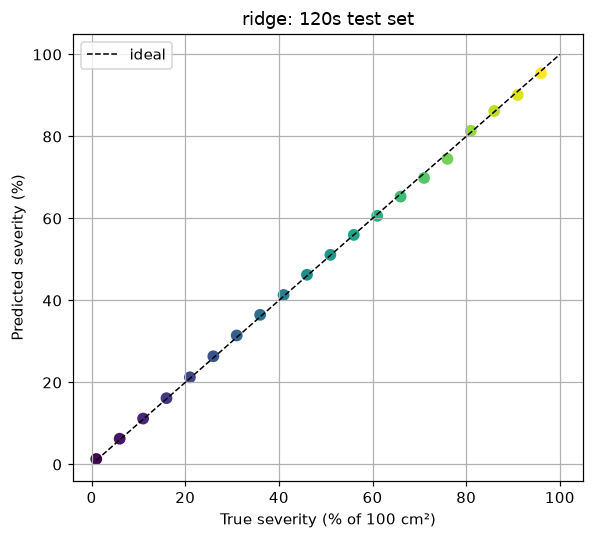

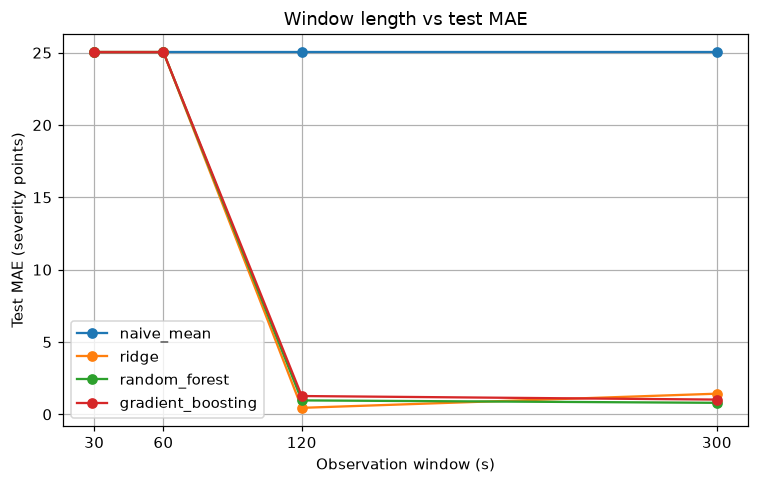

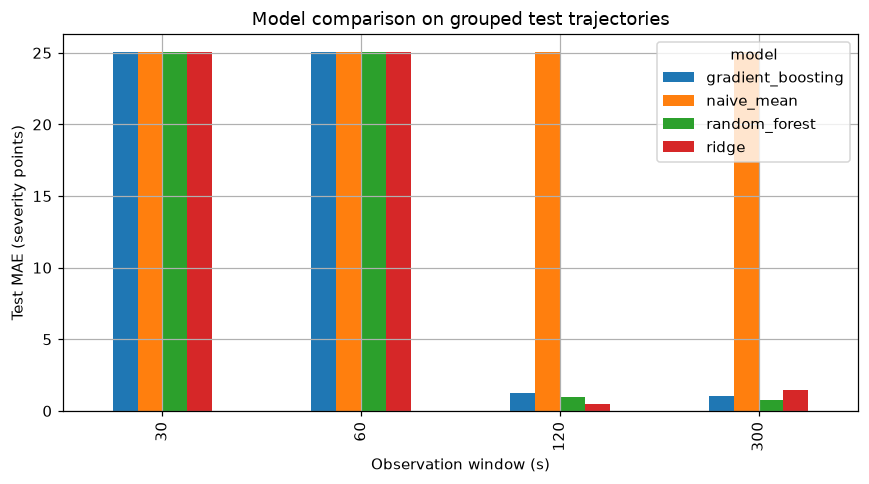

In [6]:
selected_predictions = predictions.loc[
    predictions['window_s'].eq(best_window) & predictions['model'].eq(best_model)
].sort_values('severity')

fig, ax = plt.subplots(figsize=(5.5, 5.0))
ax.scatter(selected_predictions['severity'], selected_predictions['prediction'], c=selected_predictions['severity'], cmap='viridis', s=45)
ax.plot([1, 100], [1, 100], 'k--', linewidth=1, label='ideal')
ax.set(xlabel='True severity (% of 100 cm²)', ylabel='Predicted severity (%)', title=f'{best_model}: {best_window}s test set')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '07_true_vs_predicted_severity.png', dpi=160)
plt.show()

strict_test = metrics.loc[(metrics['mode'].eq('strict')) & metrics['split'].eq('test')].copy()
fig, ax = plt.subplots(figsize=(7.0, 4.5))
for model_name in model_names:
    values = strict_test.loc[strict_test['model'].eq(model_name)].sort_values('window_s')
    ax.plot(values['window_s'], values['mae'], marker='o', label=model_name)
ax.set(xlabel='Observation window (s)', ylabel='Test MAE (severity points)', title='Window length vs test MAE')
ax.set_xticks(list(WINDOWS_S))
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '07_window_length_vs_mae.png', dpi=160)
plt.show()

pivot = strict_test.pivot(index='window_s', columns='model', values='mae').reindex(WINDOWS_S)
fig, ax = plt.subplots(figsize=(8.0, 4.5))
pivot.plot(kind='bar', ax=ax)
ax.set(xlabel='Observation window (s)', ylabel='Test MAE (severity points)', title='Model comparison on grouped test trajectories')
ax.legend(title='model')
fig.tight_layout()
fig.savefig(FIGURES_ROOT / '07_model_comparison.png', dpi=160)
plt.show()

In [7]:
naive_test = metrics.loc[
    metrics['mode'].eq('strict') & metrics['split'].eq('test') &
    metrics['window_s'].eq(best_window) & metrics['model'].eq('naive_mean')
].iloc[0]
best_low = low_metrics.loc[
    low_metrics['window_s'].eq(best_window) & low_metrics['model'].eq(best_model)
].iloc[0]

selected_importance = importance.loc[
    importance['window_s'].eq(best_window) & importance['model'].eq(best_model)
].head(10)

sensitivity_validation = metrics.loc[(metrics['mode'].eq('sensitivity')) & metrics['split'].eq('validation')].copy()
sensitivity_selection = sensitivity_validation.sort_values(['mae', 'rmse', 'r2'], ascending=[True, True, False]).iloc[0]
sensitivity_test = metrics.loc[
    metrics['mode'].eq('sensitivity') & metrics['split'].eq('test') &
    metrics['window_s'].eq(int(sensitivity_selection['window_s'])) & metrics['model'].eq(str(sensitivity_selection['model']))
].iloc[0]

suspicious_summary = {
    str(window_s): sorted(features) for window_s, features in flagged_by_window.items()
}
summary = {
    'experiment': 'LOCA severity estimation',
    'label_definition': 'LOCA filename 1..100 = percent of 100 cm2 break area',
    'trajectory_count': int(dataset['sample_id'].nunique()),
    'candidate_process_feature_count': len(candidate_features),
    'derived_feature_count': len(feature_columns),
    'windows_s': list(WINDOWS_S),
    'window_sample_points': window_summary[['window_s', 'sample_count', 'first_sample_s', 'last_sample_s', 'sample_points_s']].to_dict(orient='records'),
    'split_trajectory_counts': split_manifest['split'].value_counts().to_dict(),
    'validation_selected_best': {'window_s': best_window, 'model': best_model, 'validation_mae': float(selection['mae']), 'validation_rmse': float(selection['rmse']), 'validation_r2': float(selection['r2'])},
    'test_metrics': {'window_s': best_window, 'model': best_model, 'mae': float(best_test['mae']), 'rmse': float(best_test['rmse']), 'r2': float(best_test['r2'])},
    'naive_test_metrics_same_window': {'mae': float(naive_test['mae']), 'rmse': float(naive_test['rmse']), 'r2': float(naive_test['r2'])},
    'mae_improvement_vs_naive': float(naive_test['mae'] - best_test['mae']),
    'low_severity_test_metrics': {'n': int(best_low['n_trajectories']), 'mae': float(best_low['mae']), 'rmse': float(best_low['rmse']), 'r2': float(best_low['r2'])},
    'leakage_audit': {'train_correlation_threshold': 0.95, 'flagged_features_by_window': suspicious_summary, 'sensitivity_file': 'results/07_leakage_sensitivity.csv', 'sensitivity_validation_selected': {'window_s': int(sensitivity_selection['window_s']), 'model': str(sensitivity_selection['model']), 'validation_mae': float(sensitivity_selection['mae']), 'test_mae': float(sensitivity_test['mae']), 'test_rmse': float(sensitivity_test['rmse']), 'test_r2': float(sensitivity_test['r2'])}},
    'selected_feature_importance_top10': selected_importance.to_dict(orient='records'),
    'figures': ['results/figures/07_true_vs_predicted_severity.png', 'results/figures/07_window_length_vs_mae.png', 'results/figures/07_model_comparison.png'],
}
(RESULTS_ROOT / '07_severity_summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')

assert (RESULTS_ROOT / '07_severity_metrics.csv').exists()
assert (RESULTS_ROOT / '07_low_severity_test_metrics.csv').exists()
assert (RESULTS_ROOT / '07_severity_summary.json').exists()
assert all((FIGURES_ROOT / name).exists() for name in ['07_true_vs_predicted_severity.png', '07_window_length_vs_mae.png', '07_model_comparison.png'])
assert best_test['mae'] >= 0 and best_test['rmse'] >= 0
print(f'Validation-selected best: {best_model} / {best_window}s')
print(f'Final grouped-test result: MAE={best_test.mae:.3f}, RMSE={best_test.rmse:.3f}, R2={best_test.r2:.3f}')
print(f'Low severity 1-10, n={int(best_low.n_trajectories)}: MAE={best_low.mae:.3f}, RMSE={best_low.rmse:.3f}, R2={best_low.r2:.3f}')
print(f'Naive same-window MAE={naive_test.mae:.3f}; improvement={naive_test.mae - best_test.mae:.3f}')
print(f'Sensitivity-selected pair after train-only exclusions: {sensitivity_selection.model} / {int(sensitivity_selection.window_s)}s; test MAE={sensitivity_test.mae:.3f}')
print('Top selected features:')
display(selected_importance)
print('FULL LOCA SEVERITY ESTIMATION PASSED')

Validation-selected best: ridge / 120s
Final grouped-test result: MAE=0.449, RMSE=0.567, R2=1.000
Low severity 1-10, n=2: MAE=0.302, RMSE=0.303, R2=0.985
Naive same-window MAE=25.050; improvement=24.601
Sensitivity-selected pair after train-only exclusions: random_forest / 120s; test MAE=0.972
Top selected features:


,window_s,model,rank,feature,importance
120,120,ridge,1,VOL__last,1.381480
121,120,ridge,2,VOL__delta_t0,1.381480
122,120,ridge,3,LVPZ__last,1.381480
123,120,ridge,4,LVPZ__delta_t0,1.381480
124,120,ridge,5,VOL__std,1.380448
125,120,ridge,6,LVPZ__std,1.380447
126,120,ridge,7,VOL__slope,1.377805
127,120,ridge,8,LVPZ__slope,1.377803
128,120,ridge,9,VOL__mean,1.377152
129,120,ridge,10,LVPZ__mean,1.377150


FULL LOCA SEVERITY ESTIMATION PASSED
